In [7]:
#당뇨병 분류(결정트리->랜덤포레스트(배깅))
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv('../datasets/pima-indians-diabetes.csv', names=cols)

print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [8]:
# 독립변수(X), 종속변수(y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 학습 / 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

# 1. 결정트리
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

print('결정트리 학습 정확도:', tree.score(X_train, y_train))  #r: 결정트리 학습 정확도: 0.8241042345276873
print('결정트리 테스트 정확도:', tree.score(X_test, y_test))  #r: 결정트리 테스트 정확도: 0.7922077922077922

결정트리 학습 정확도: 0.8241042345276873
결정트리 테스트 정확도: 0.7922077922077922


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 2. 랜덤포레스트
forest = RandomForestClassifier(
    n_estimators=200,  #결정트리를 200개 만들겠다
    max_depth=7,
    max_samples=0.7,  #각각의 트리가 학습할 때 전체 학습 데이터 중 70%를 복원추출(bootstrap sampling)해서 사용
    max_features='sqrt', #각 노드의 분할에서도 일부 변수만 무작위로 후보로 선택
    random_state=42
)
# max_features='sqrt'
## 데이터를 70% 뽑는 것이 아니라 각 노드에서 분할 기준을 찾을 때 사용할 변수들을 무작위로 일부만 선택

#Random Forest는 데이터도 무작위로 뽑고(max_samples) + 특성도 무작위로 뽑아서(max_features) 
## → 서로 조금씩 다른 결정트리를 여러 개 만들고 → 여러 트리의 예측을 종합해 최종 분류한다
forest.fit(X_train, y_train)

print('랜덤포레스트 학습 정확도:', forest.score(X_train, y_train)) #r: 랜덤포레스트 학습 정확도: 0.9153094462540716
print('랜덤포레스트 테스트 정확도:', forest.score(X_test, y_test)) #r: 랜덤포레스트 테스트 정확도: 0.7532467532467533

# 예측
y_pred = forest.predict(X_test)

print('\n분류 보고서')
print(classification_report(y_test, y_pred))

랜덤포레스트 학습 정확도: 0.9153094462540716
랜덤포레스트 테스트 정확도: 0.7532467532467533

분류 보고서
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



C:\Users\301-21\AppData\Local\Temp\ipykernel_456\2699226731.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


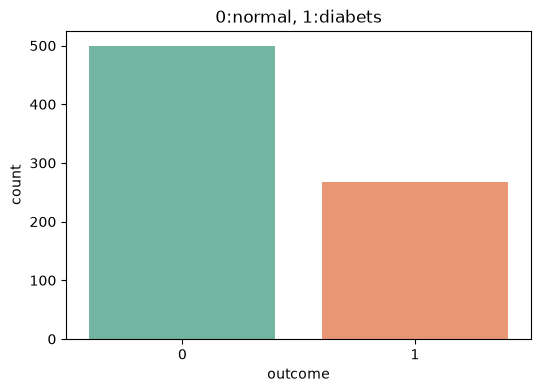

In [13]:
#타겟 변수 분포 :0과 1의 개수 차이를 보고 타깃 클래스 불균형(class imbalance)이 어느 정도 있는지 확인
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('0:normal, 1:diabets'); plt.xlabel('outcome'); plt.ylabel('count'); plt.show()

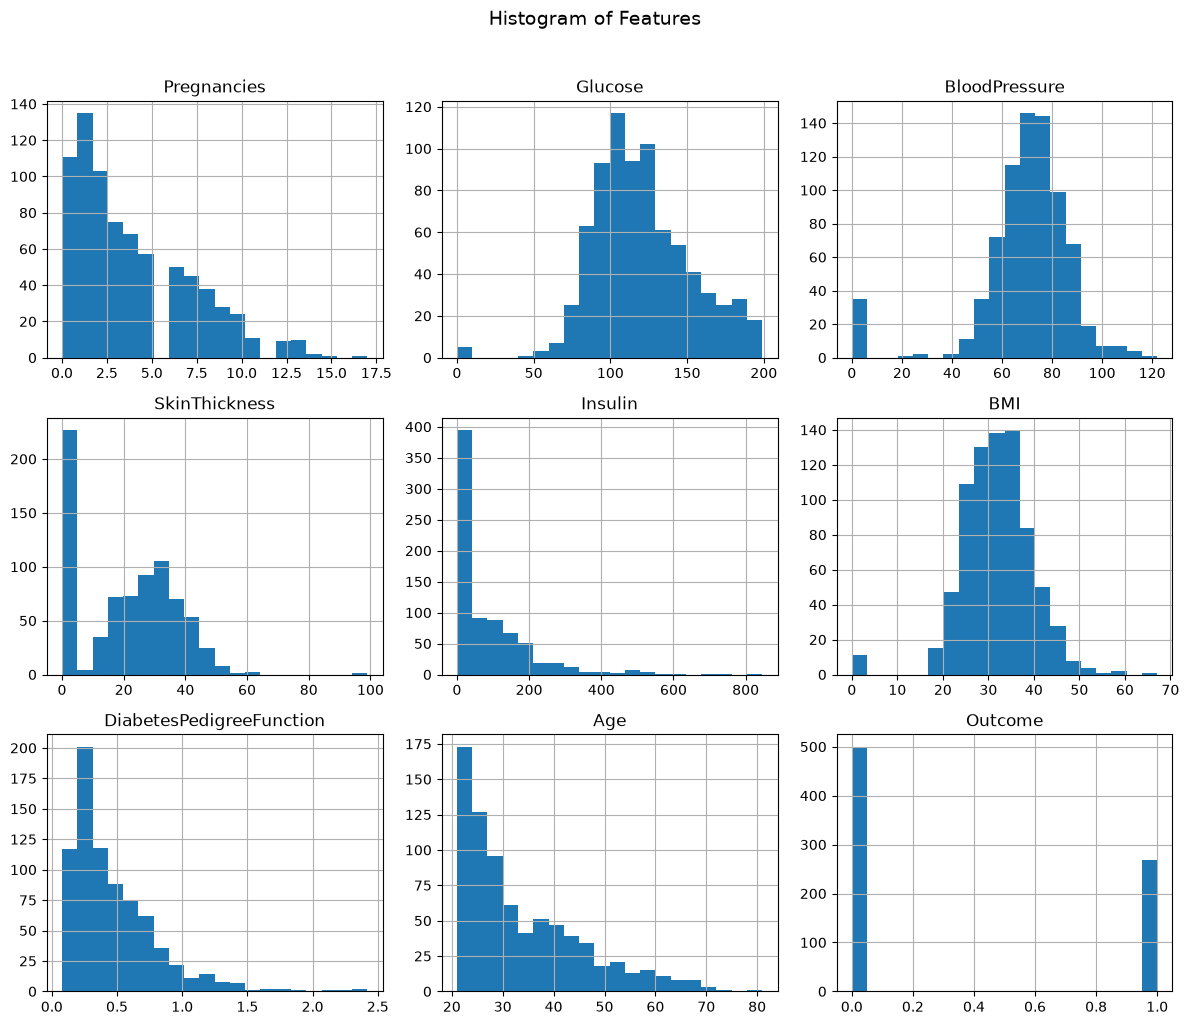

In [16]:
# 각 특징들의 분포
df.hist(figsize=(12, 10), bins=20, grid=True)
plt.suptitle('Histogram of Features', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()


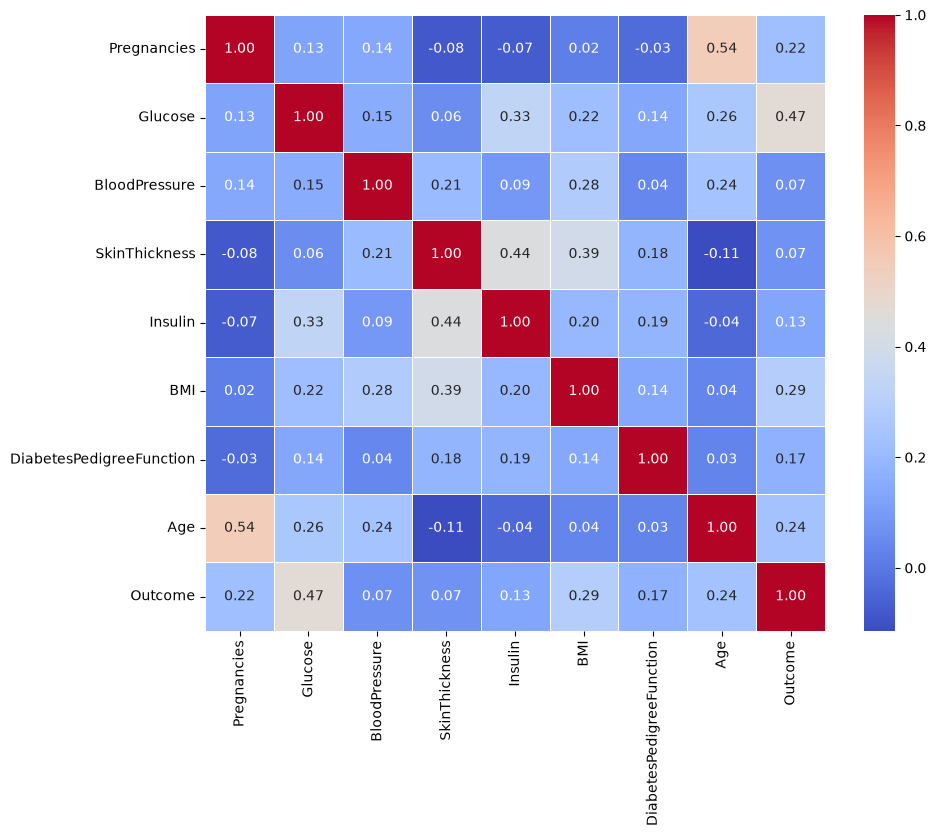

In [17]:
#변수간 상관관계
plt.figure(figsize=(10,8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

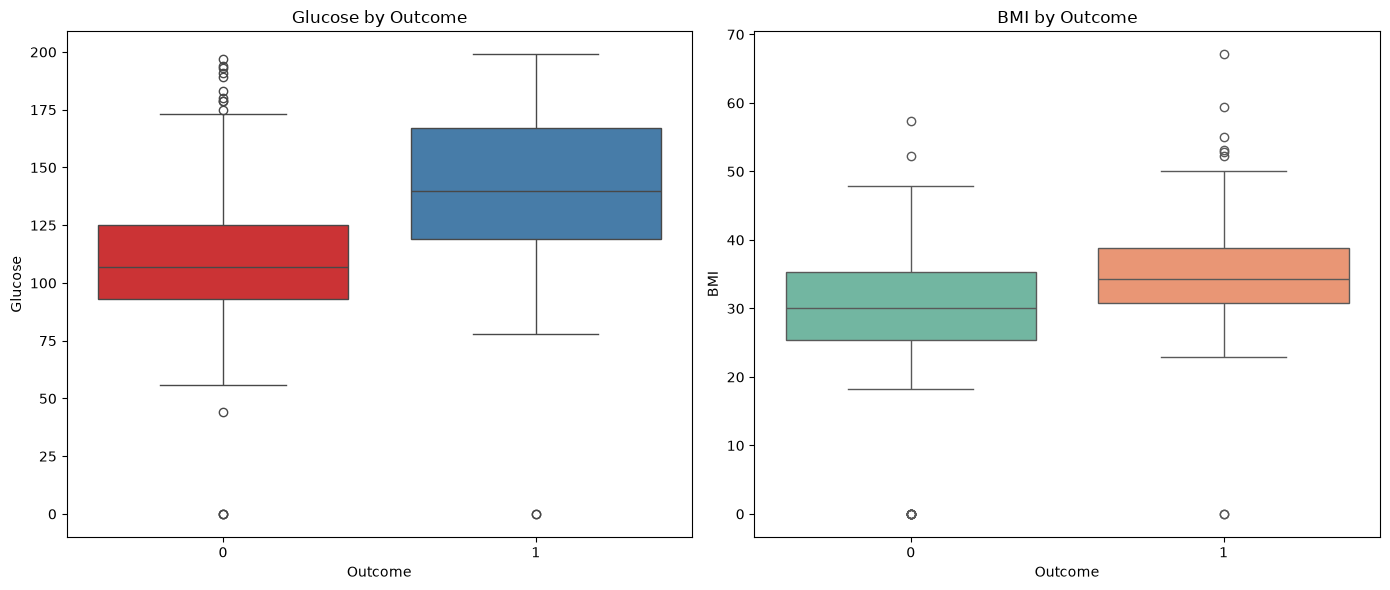

In [19]:
#BMI & Glucose
plt.figure(figsize=(14, 6))
# 왼쪽: Glucose
plt.subplot(1, 2, 1)
sns.boxplot(x='Outcome',y='Glucose',data=df, hue='Outcome',palette='Set1', legend=False)
plt.title('Glucose by Outcome')

# 오른쪽: BMI
plt.subplot(1, 2, 2)  # ★ 여기가 2
sns.boxplot(x='Outcome',y='BMI', data=df, hue='Outcome',palette='Set2', legend=False)
plt.title('BMI by Outcome')

plt.tight_layout()
plt.show()
#당뇨병 환자군(Outcome=1)은 비당뇨군(Outcome=0)에 비해 Glucose와 BMI가 모두 높은 분포를 보이며, 
#특히 Glucose에서 두 집단의 차이가 더 뚜렷하게 나타sk

In [26]:
# Decision Tree
x = df.drop('Outcome', axis=1)
y = df['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=1, stratify=y)
tree = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,random_state=1)
tree.fit(x_train, y_train)

print('결정트리 정확도(단일분할):', round(tree.score(x_test, y_test), 3))

결정트리 정확도(단일분할): 0.75


In [30]:
# 데이터 분할 방식에 따른 정확도가 변해
for rs in [0, 1, 2, 3, 4]:
    # random_state를 바꾸면서 데이터 분할
    x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=rs,stratify=y)
    # 결정트리 생성
    tree = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,random_state=1)
    # 학습
    tree.fit(x_train, y_train)
    # 정확도 출력
    print(f'결정트리 정확도(rs={rs}):', round(tree.score(x_test, y_test), 3))

결정트리 정확도(rs=0): 0.781
결정트리 정확도(rs=1): 0.75
결정트리 정확도(rs=2): 0.698
결정트리 정확도(rs=3): 0.703
결정트리 정확도(rs=4): 0.708


In [33]:
# 교차검증(Cross Validation) - Stratified K-Fold
from sklearn.model_selection import cross_val_score, StratifiedKFold
# 5개의 Fold로 분할
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=1)

# 결정트리 5-Fold 교차검증
tree_cv = cross_val_score(DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=1),x,y,cv=cv)

print('결정트리 5-fold 점수:', np.round(tree_cv, 3))
print('교차검증 평균 정확도:', round(tree_cv.mean(), 3))
# 1회: [테스트] [학습] [학습] [학습] [학습]
# 2회: [학습] [테스트] [학습] [학습] [학습]
# 3회: [학습] [학습] [테스트] [학습] [학습]
# 4회: [학습] [학습] [학습] [테스트] [학습]
# 5회: [학습] [학습] [학습] [학습] [테스트]
#처럼 모든 데이터가 한 번씩 검증(test) 역할
#StratifiedKFold를 사용했기 때문에 각 Fold에서 Outcome=0과 Outcome=1의 비율도 원래 데이터와 비슷하게 유지
##각 숫자는 각 Fold에서 얻은 정확도이고, 0.760은 5번의 정확도를 평균낸 값
#앞에서 한 번만 나눴을 때 정확도가 0.73, 0.78처럼 흔들렸다면, 
#교차검증에서는 여러 번 평가한 평균값을 사용하기 때문에 모델의 일반화 성능을 좀 더 안정적으로 추정

결정트리 5-fold 점수: [0.747 0.773 0.753 0.699 0.739]
교차검증 평균 정확도: 0.742


In [36]:
#랜덤포레스트(여러 트리 다수결)
from sklearn.ensemble import RandomForestClassifier
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=1), x, y, cv=cv)
print(f'랜덤포레스트 5-fold 점수:', np.round(rf_cv, 3))
print(f'평균:{round(rf_cv.mean(),3)}')
#랜덤포레스트의 평균 정확도가 더 높고, Fold별 정확도도 비교적 안정적
##결정트리 하나에 의존하지 않고 여러 결정트리를 만들어 각각 예측시킨 다음 다수결로 최종 분류
#단일 결정트리보다 특정 데이터 분할에 대한 민감도와 분산을 줄이는 효과

랜덤포레스트 5-fold 점수: [0.753 0.805 0.812 0.745 0.725]
평균:0.768


In [39]:
#하이퍼파라미터 튜닝-GridSearchCV
#여러 설정 조합을 교차검증으로 다 시험 후 좋은 설정을 찾기
from sklearn.model_selection import GridSearchCV
rf_grid = GridSearchCV(RandomForestClassifier(random_state=1), 
                       {'n_estimators':[100, 200,300,400], 'max_depth':[4,6,8,None], 'min_samples_leaf':[1,3,5,7]},
                       cv=cv, scoring='accuracy').fit(x,y)
print('랜덤포레스트 튜닝 최고:', round(rf_grid.best_score_, 3),rf_grid.best_params_)

#4 × 4 × 4 = 64개 조합을 시험
##cv를 5-Fold로 만들었으므로 각 조합을 5번씩 검증(64개 설정 × 5-Fold = 총 320번의 모델 학습)
#r: GridSearchCV가 시험한 64개 하이퍼파라미터 조합 중, 아래 설정이 5-Fold 교차검증에서 가장 높은 평균 정확도 0.776 = 77.6%를 기록했다

랜덤포레스트 튜닝 최고: 0.776 {'max_depth': None, 'min_samples_leaf': 3, 'n_estimators': 300}


In [41]:
print('기본 랜덤포레스트 평균:', round(rf_cv.mean(), 3))
print('튜닝 랜덤포레스트 평균:', round(rf_grid.best_score_, 3))
#기본 모델이 0.768, 튜닝 모델이 0.776이라면:
##해석: "기본 Random Forest의 5-Fold 평균 정확도는 76.8%였으며, GridSearchCV를 통해 하이퍼파라미터를 최적화한 결과 77.6%로 약 0.8%p 향상되었다."
#현재 실험에서는 트리 300개 + 깊이 제한 없음 + leaf 최소 3개 조합이 가장 좋았고, 교차검증 평균 정확도는 77.6%였습니다.

기본 랜덤포레스트 평균: 0.768
튜닝 랜덤포레스트 평균: 0.776


In [42]:
#오차에 집중해 순차적을 트리를 쌓는  GradientBoosting
from sklearn.ensemble import GradientBoostingClassifier
gb_cv = cross_val_score(GradientBoostingClassifier(random_state=1), x,y, cv=cv)
print(f'그래디언트부스팅 평균:{round(gb_cv.mean(),3)}') #r: 0.755


그래디언트부스팅 평균:0.755


In [50]:
# Gradient Boosting 하이퍼파라미터 튜닝
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=1), 
                       {'n_estimators': [100, 200, 300, 400], 'learning_rate': [0.01, 0.05, 0.1],'max_depth': [4, 6, 8, None]},
                       cv=cv, scoring='accuracy').fit(x, y)
print(f'부스팅 튜닝: {round(gb_grid.best_score_, 3)}, 'f'{gb_grid.best_params_}')

부스팅 튜닝: 0.772, {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300}


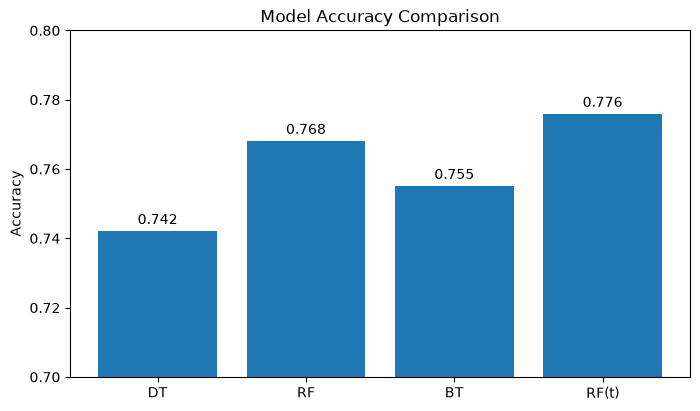

In [54]:
result = {
    'DT': tree_cv.mean(),
    'RF': rf_cv.mean(),
    'BT': gb_cv.mean(),
    'RF(t)': rf_grid.best_score_
}

plt.figure(figsize=(8, 4.5))

bars = plt.bar(
    list(result.keys()),
    list(result.values())
)

plt.ylim(0.70, 0.80)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

# 막대 위에 정확도 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f'{height:.3f}',
        ha='center'
    )

plt.show()

In [55]:
# GridSearchCV에서 찾은 최적 Random Forest
best_rf = rf_grid.best_estimator_

# 최적 모델을 train 데이터로 다시 학습
best_rf.fit(x_train, y_train)

# test 데이터 예측
pred = best_rf.predict(x_test)

# 혼동행렬
print('혼동행렬 (0: 정상, 1: 당뇨)')
print(confusion_matrix(y_test, pred))

print()

# 분류 보고서
print(classification_report(
    y_test,
    pred,
    target_names=['정상', '당뇨']
))

#94명은 실제 정상인데 정상으로 정확하게 예측했습니다(TN). 
#31명은 실제 정상인데 당뇨라고 잘못 예측했습니다(FP). 
#23명은 실제 당뇨인데 정상이라고 잘못 예측했습니다(FN). 
#44명은 실제 당뇨인데 당뇨라고 정확하게 예측했습니다(TP).
##FN=23을 주의해서 봐야 합니다. 실제 당뇨 환자 67명 중 23명을 정상으로 판단해서 놓침
#전체 정확도 : accuracy = 0.72 
## 전체 192명 중 정확하게 맞힌 사람은 94 + 44 = 138명 / 72% 정확하게 분류

# 당뇨
# precision = 0.59  : 모델이 당뇨라고 예측한 사람 중 실제로 당뇨인 사람이 약 59%
# recall    = 0.66
# f1-score  = 0.62  : F1-score=0.62는 precision과 recall을 종합한 지표(당뇨 클래스에 대한 분류 성능은 정상 클래스보다 낮다)
# support   = 67 /실제 당뇨 환자 중 66%를 당뇨라고 찾아냈다 
## 실제 당뇨 환자는 67명이고 그중 44명을 찾았으므로:44 / 67 ≈ 0.66  (실제 당뇨 환자의 약 34%를 놓쳤다)

# 전체 정확도는 **72%**이며, 정상에 대한 F1-score는 0.78, 당뇨에 대한 F1-score는 0.62이다. 
#특히 실제 당뇨 환자 67명 중 44명을 당뇨로 정확하게 분류하고 23명을 정상으로 잘못 분류하여, 당뇨 클래스의 재현율(recall)은 66%이다.


혼동행렬 (0: 정상, 1: 당뇨)
[[94 31]
 [23 44]]

              precision    recall  f1-score   support

          정상       0.80      0.75      0.78       125
          당뇨       0.59      0.66      0.62        67

    accuracy                           0.72       192
   macro avg       0.70      0.70      0.70       192
weighted avg       0.73      0.72      0.72       192



In [56]:
# 비교할 분류 모델들을 딕셔너리에 저장
models = {
    # DT: 단일 결정트리
    'DT': DecisionTreeClassifier(
        max_depth=5,          # 트리의 최대 깊이를 5로 제한
        random_state=1        # 실행할 때마다 같은 결과가 나오도록 난수 고정
    ),

    # RF: 랜덤포레스트
    'RF': RandomForestClassifier(
        n_estimators=300,     # 결정트리 300개를 만들어 다수결로 예측
        random_state=1
    ),

    # BT: Gradient Boosting
    'BT': GradientBoostingClassifier(
        n_estimators=100,     # 순차적으로 학습할 결정트리 개수
        learning_rate=0.1,    # 각 트리의 학습 결과를 반영하는 정도
        max_depth=3,          # 각 결정트리의 최대 깊이
        random_state=1
    ),

    # RF(t): GridSearchCV로 하이퍼파라미터를 튜닝한 최적 랜덤포레스트
    'RF(t)': rf_grid.best_estimator_
}


# 각 모델의 FN(False Negative)을 저장할 딕셔너리
fn_result = {}

# models에 저장된 모델을 하나씩 꺼내서 평가
for name, model in models.items():
    # 학습 데이터로 모델 학습
    model.fit(x_train, y_train)
    # 테스트 데이터의 당뇨병 여부 예측
    pred = model.predict(x_test)
    # 실제값과 예측값을 이용하여 혼동행렬 생성
    cm = confusion_matrix(y_test, pred)
    # 혼동행렬의 4개 값을 각각 분리
    # TN: 실제 정상 → 정상으로 예측
    # FP: 실제 정상 → 당뇨로 잘못 예측
    # FN: 실제 당뇨 → 정상으로 잘못 예측 (당뇨 환자를 놓침)
    # TP: 실제 당뇨 → 당뇨로 예측
    tn, fp, fn, tp = cm.ravel()

    # 모델별 FN 값을 딕셔너리에 저장
    fn_result[name] = fn

    # 모델별 혼동행렬 출력
    print(f'\n{name} 혼동행렬')
    print(cm)

    # TN, FP, FN, TP 출력
    print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')


# 각 모델의 FN 중 가장 작은 값의 모델 찾기
# FN이 작을수록 실제 당뇨 환자를 정상으로 잘못 판단하는 경우가 적음
best_fn_model = min(fn_result, key=fn_result.get)


# 모델별 FN 비교
print('\n모델별 FN:', fn_result)

# FN이 가장 낮은 모델과 FN 값 출력
print(
    f'FN이 가장 낮은 모델: {best_fn_model}, '
    f'FN={fn_result[best_fn_model]}'
)
#r: FN이 가장 낮은 모델은 DT와 RF(t)이며, 둘 다 FN=23
##


DT 혼동행렬
[[95 30]
 [23 44]]
TN=95, FP=30, FN=23, TP=44

RF 혼동행렬
[[92 33]
 [24 43]]
TN=92, FP=33, FN=24, TP=43

BT 혼동행렬
[[92 33]
 [27 40]]
TN=92, FP=33, FN=27, TP=40

RF(t) 혼동행렬
[[94 31]
 [23 44]]
TN=94, FP=31, FN=23, TP=44

모델별 FN: {'DT': np.int64(23), 'RF': np.int64(24), 'BT': np.int64(27), 'RF(t)': np.int64(23)}
FN이 가장 낮은 모델: DT, FN=23
